<a href="https://colab.research.google.com/github/Sumit-Sahu90/Road-Safety-Analysis/blob/main/Day13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# Load the dataset
dataset_path = "/content/drive/MyDrive/data/raw/US_Accidents_March23.csv"
accidents_df = pd.read_csv(dataset_path)


Univariate Analysis
Definition:

Univariate analysis examines and describes a single variable or feature in a dataset. The goal is to understand the distribution, central tendency (mean, median, mode), spread (variance, standard deviation), and shape (skewness, kurtosis) of that variable. Common tools include frequency counts, histograms, bar charts, and boxplots.

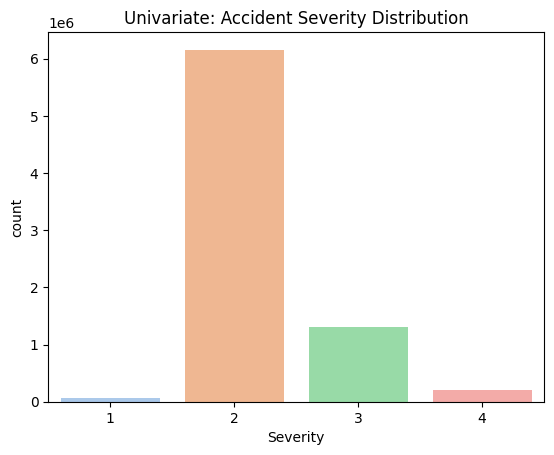

In [ ]:

# --- UNIVARIATE ANALYSIS ---
# Distribution of 'Severity' (categorical)
sns.countplot(x='Severity', data=accidents_df, palette='pastel')
plt.title('Univariate: Accident Severity Distribution')
plt.show()


Bivariate Analysis
Definition:

Bivariate analysis explores the relationship between exactly two variables (X and Y) to discover whether they are related and, if so, how. It helps analyze the nature, strength, and direction of the association—using methods such as correlation, scatter plots, cross-tabulation, boxplots, and regression. Examples include height vs. weight, or accident severity vs. weather condition

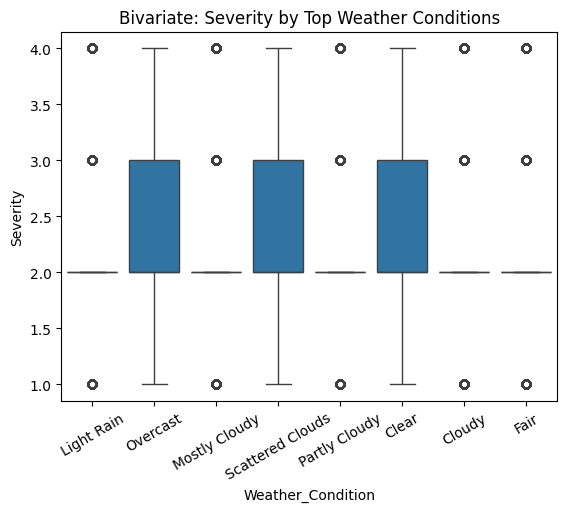

In [ ]:

# --- BIVARIATE ANALYSIS ---
# Relationship between Severity and Weather_Condition (categorical vs. categorical)
top_weather = accidents_df['Weather_Condition'].value_counts().nlargest(8)
sns.boxplot(x='Weather_Condition', y='Severity',
            data=accidents_df[accidents_df['Weather_Condition'].isin(top_weather.index)])
plt.title('Bivariate: Severity by Top Weather Conditions')
plt.xticks(rotation=30)
plt.show()


Multivariate Analysis
Definition:

Multivariate analysis studies three or more variables simultaneously to uncover complex relationships, patterns, and interactions among them. It can show how multiple factors together influence an outcome—using techniques like heatmaps, pairplots, multiple regression, and principal component analysis. Examples include examining how weather, hour, and traffic conditions together affect accident severity

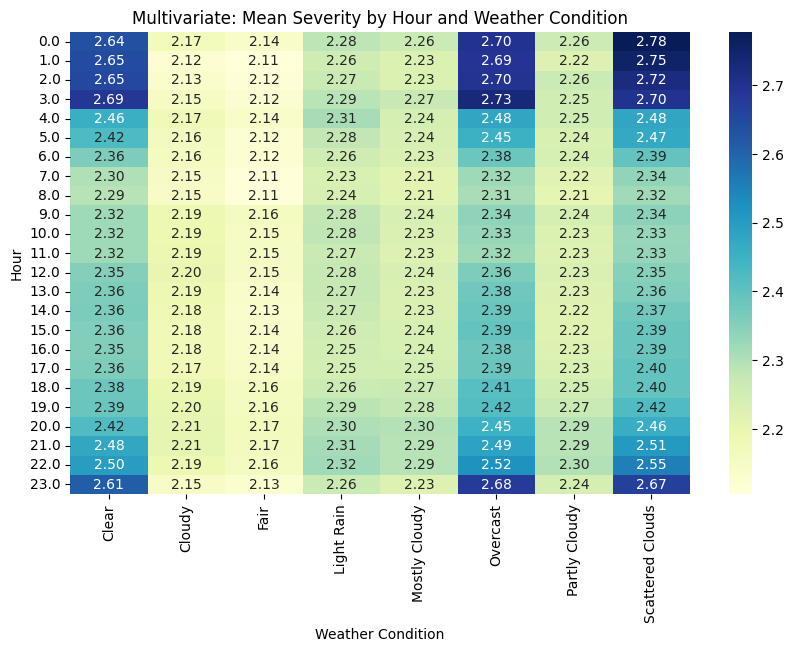

In [ ]:

# --- MULTIVARIATE ANALYSIS ---
# Severity by Hour and Top Weather Conditions (heatmap)
if 'Hour' not in accidents_df:
    accidents_df['Hour'] = pd.to_datetime(accidents_df['Start_Time'], errors='coerce').dt.hour
pivot = accidents_df[accidents_df['Weather_Condition'].isin(top_weather.index)].pivot_table(
    values='Severity', index='Hour', columns='Weather_Condition', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Multivariate: Mean Severity by Hour and Weather Condition')
plt.ylabel('Hour')
plt.xlabel('Weather Condition')
plt.show()


Basic Statistics

In [ ]:
# --- Summary statistics for all numerical columns ---
print("Summary statistics for numerical columns:")
display(accidents_df.describe().T)

Summary statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
Severity,7728394.0,2.212384,0.487531,1.000000,2.000000,2.000000,2.000000,4.000000
Start_Lat,7728394.0,36.201195,5.076079,24.554800,33.399631,35.823974,40.084959,49.002201
Start_Lng,7728394.0,-94.702545,17.391756,-124.623833,-117.219396,-87.766616,-80.353676,-67.113167
End_Lat,4325632.0,36.261829,5.272905,24.566013,33.462070,36.183495,40.178920,49.075000
End_Lng,4325632.0,-95.725570,18.107928,-124.545748,-117.754345,-88.027890,-80.247086,-67.109242
Distance(mi),7728394.0,0.561842,1.776811,0.000000,0.000000,0.030000,0.464000,441.750000
Temperature(F),7564541.0,61.663286,19.013653,-89.000000,49.000000,64.000000,76.000000,207.000000
Wind_Chill(F),5729375.0,58.251048,22.389832,-89.000000,43.000000,62.000000,75.000000,207.000000
Humidity(%),7554250.0,64.831041,22.820968,1.000000,48.000000,67.000000,84.000000,100.000000
Pressure(in),7587715.0,29.538986,1.006190,0.000000,29.370000,29.860000,30.030000,58.630000


In [ ]:
# --- Additional statistics: median for each numerical column ---
print("\nMedian values for numerical columns:")
display(accidents_df.median(numeric_only=True))


Median values for numerical columns:


,0
Severity,2.000000
Start_Lat,35.823974
Start_Lng,-87.766616
End_Lat,36.183495
End_Lng,-88.027890
Distance(mi),0.030000
Temperature(F),64.000000
Wind_Chill(F),62.000000
Humidity(%),67.000000
Pressure(in),29.860000



Severity value counts:
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64


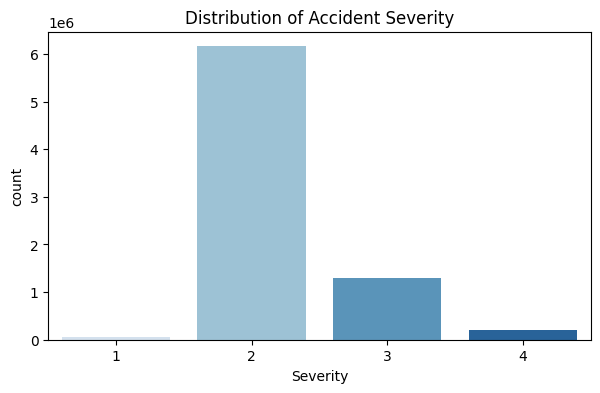

In [ ]:

# --- Explore distributions and ranges for key features ---

# 1. Severity
print("\nSeverity value counts:")
print(accidents_df['Severity'].value_counts().sort_index())

plt.figure(figsize=(7, 4))
sns.countplot(x='Severity', data=accidents_df, palette='Blues')
plt.title('Distribution of Accident Severity')
plt.show()

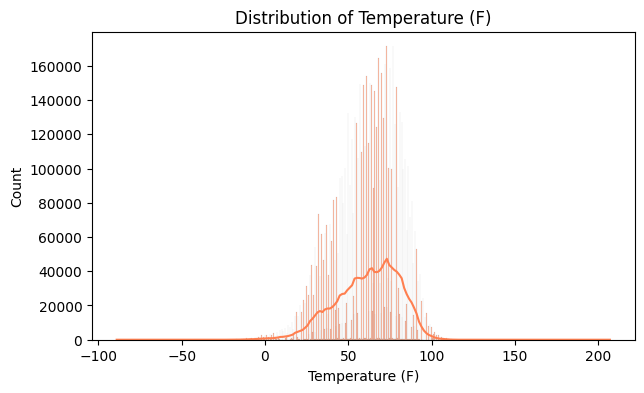

Temperature (F): min = -89.0 | max = 207.0


In [ ]:

# 2. Temperature
plt.figure(figsize=(7, 4))
sns.histplot(accidents_df['Temperature(F)'].dropna(), kde=True, color='coral')
plt.title('Distribution of Temperature (F)')
plt.xlabel('Temperature (F)')
plt.show()
print("Temperature (F): min =", accidents_df['Temperature(F)'].min(),
      "| max =", accidents_df['Temperature(F)'].max())

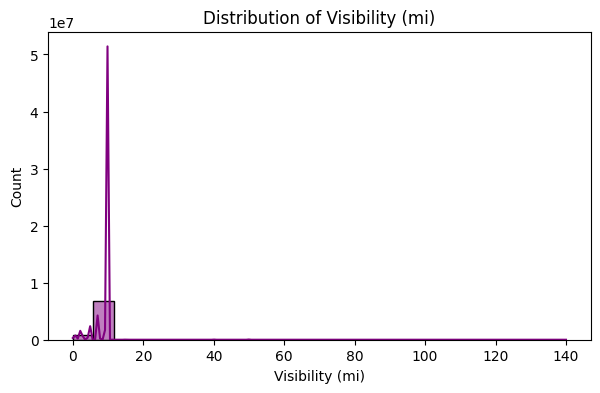

Visibility (mi): min = 0.0 | max = 140.0


In [ ]:

# 3. Visibility
plt.figure(figsize=(7, 4))
sns.histplot(accidents_df['Visibility(mi)'].dropna(), kde=True, color='purple')
plt.title('Distribution of Visibility (mi)')
plt.xlabel('Visibility (mi)')
plt.show()
print("Visibility (mi): min =", accidents_df['Visibility(mi)'].min(),
      "| max =", accidents_df['Visibility(mi)'].max())

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


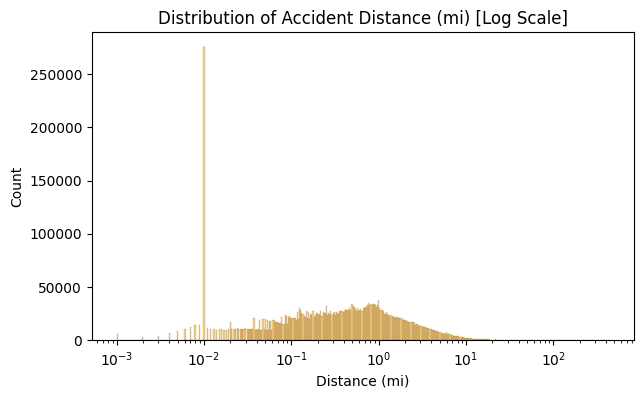

Distance (mi): min = 0.0 | max = 441.75


In [ ]:

# 4. Distance
plt.figure(figsize=(7, 4))
# Use log scale due to highly skewed distance distribution
sns.histplot(accidents_df['Distance(mi)'].dropna(), kde=True, color='orange', log_scale=True)
plt.title('Distribution of Accident Distance (mi) [Log Scale]')
plt.xlabel('Distance (mi)')
plt.show()
print("Distance (mi): min =", accidents_df['Distance(mi)'].min(),
      "| max =", accidents_df['Distance(mi)'].max())


Most frequent Weather Conditions:
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Light Snow           128680
Fog                   99238
Name: count, dtype: int64


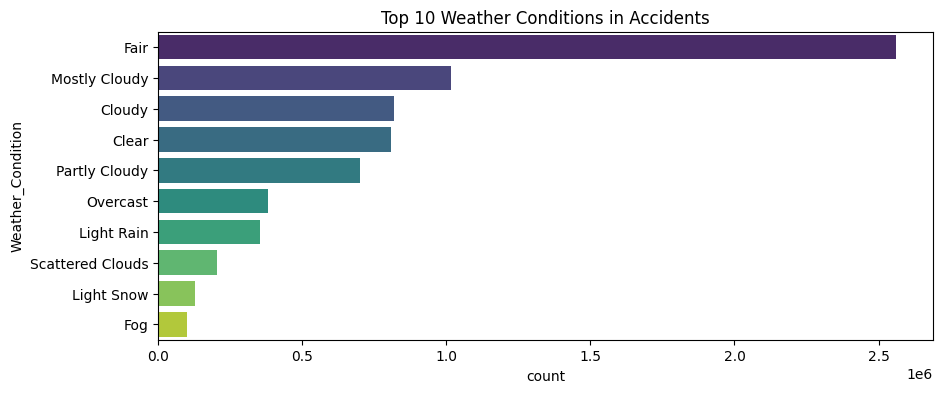

In [ ]:

# 5. Explore Weather Condition categories
print("\nMost frequent Weather Conditions:")
print(accidents_df['Weather_Condition'].value_counts(dropna=True).head(10))

plt.figure(figsize=(10, 4))
sns.countplot(y='Weather_Condition', data=accidents_df,
              order=accidents_df['Weather_Condition'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Weather Conditions in Accidents')
plt.show()

In [ ]:
# 6. Explore distribution over latitude and longitude (range)
print("\nLatitude range:", accidents_df['Start_Lat'].min(), "to", accidents_df['Start_Lat'].max())
print("Longitude range:", accidents_df['Start_Lng'].min(), "to", accidents_df['Start_Lng'].max())


Latitude range: 24.5548 to 49.002201
Longitude range: -124.623833 to -67.113167
